In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"D:\ocally assignment\business_daily.csv")
df["date"] = pd.to_datetime(df["date"])

In [16]:
print(f"shape:\n {df.shape}\n")
print(f"datatypes:\n {df.dtypes}\n")
print(f"total null values:\n {df.isnull().sum()}")
print(f"unique buisnesses: \n {df["business_id"].unique()}")

shape:
 (3028, 9)

datatypes:
 date                datetime64[us]
business_id                    str
revenue                    float64
visits                       int64
review_count                 int64
avg_rating                 float64
is_weekend                   int64
local_event_flag             int64
marketing_spend            float64
dtype: object

total null values:
 date                0
business_id         0
revenue             0
visits              0
review_count        0
avg_rating          0
is_weekend          0
local_event_flag    0
marketing_spend     0
dtype: int64
unique buisnesses: 
 <StringArray>
[  'blue_bottle_cafe',      'corner_bakery', 'evergreen_boutique',
     'iron_pulse_gym',    'nonna_trattoria', 'shear_genius_salon']
Length: 6, dtype: str


In [20]:
df.head()

,date,business_id,revenue,visits,review_count,avg_rating,is_weekend,local_event_flag,marketing_spend
0,2024-07-01,blue_bottle_cafe,1843.53,151,321,4.50,0,0,0.0
1,2024-07-01,corner_bakery,413.31,35,95,4.59,0,0,0.0
2,2024-07-01,evergreen_boutique,1712.70,35,60,4.31,0,0,0.0
3,2024-07-01,iron_pulse_gym,3867.09,121,220,3.90,0,0,0.0
4,2024-07-01,nonna_trattoria,2993.61,74,410,4.40,0,0,0.0


In [22]:
df.tail()

,date,business_id,revenue,visits,review_count,avg_rating,is_weekend,local_event_flag,marketing_spend
3023,2025-12-31,corner_bakery,839.62,76,170,4.79,0,0,0.0
3024,2025-12-31,evergreen_boutique,1727.21,42,88,4.62,0,0,0.0
3025,2025-12-31,iron_pulse_gym,2610.95,75,303,3.64,0,0,0.0
3026,2025-12-31,nonna_trattoria,3188.75,103,688,4.94,0,0,0.0
3027,2025-12-31,shear_genius_salon,6171.36,92,359,4.75,0,0,0.0


In [25]:
full_range = pd.date_range("2024-07-01", "2025-12-31")
print(len(full_range))

549


In [29]:
# there are 6 unique buisnesses and total 549 days so total rows should be 

549 * 6  

3294

In [26]:
for biz in df["business_id"].unique():
    reported = df[df["business_id"] == biz]["date"]
    missing = full_range.difference(reported)
    print(f"{biz}: {len(reported)} reported, {len(missing)} missing")

blue_bottle_cafe: 549 reported, 0 missing
corner_bakery: 400 reported, 149 missing
evergreen_boutique: 549 reported, 0 missing
iron_pulse_gym: 432 reported, 117 missing
nonna_trattoria: 549 reported, 0 missing
shear_genius_salon: 549 reported, 0 missing


### revenue distribution per buisness

In [30]:
for biz in df["business_id"].unique():
    sub = df[df["business_id"] == biz]["revenue"]
    print(f"{biz}: mean={sub.mean():.0f}, std={sub.std():.0f}, "
          f"min={sub.min():.0f}, max={sub.max():.0f}, skew={sub.skew():.2f}")

blue_bottle_cafe: mean=2793, std=901, min=1070, max=6808, skew=0.95
corner_bakery: mean=613, std=316, min=65, max=2238, skew=1.19
evergreen_boutique: mean=1763, std=263, min=1183, max=2670, skew=0.44
iron_pulse_gym: mean=2626, std=892, min=925, max=6681, skew=0.78
nonna_trattoria: mean=6075, std=2764, min=1852, max=21664, skew=1.49
shear_genius_salon: mean=3225, std=1564, min=691, max=8923, skew=0.64


### weekly seasonality

In [32]:
df["dayofweek"] = df["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekly = df.groupby(["business_id", "dayofweek"])["revenue"].mean().unstack()
print(weekly[order].round(0))

dayofweek           Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  \
business_id                                                                  
blue_bottle_cafe    2182.0   2078.0     2225.0    2497.0  3192.0    3878.0   
corner_bakery        383.0    357.0      459.0     525.0   697.0     996.0   
evergreen_boutique  1657.0   1755.0     1810.0    1815.0  1842.0    1854.0   
iron_pulse_gym      3379.0   3047.0     2895.0    2752.0  2520.0    1915.0   
nonna_trattoria     3794.0   3986.0     4321.0    5404.0  7679.0    9448.0   
shear_genius_salon  2299.0   3102.0     3379.0    3683.0  4185.0    4701.0   

dayofweek           Sunday  
business_id                 
blue_bottle_cafe    3527.0  
corner_bakery        847.0  
evergreen_boutique  1608.0  
iron_pulse_gym      1790.0  
nonna_trattoria     7968.0  
shear_genius_salon  1240.0  


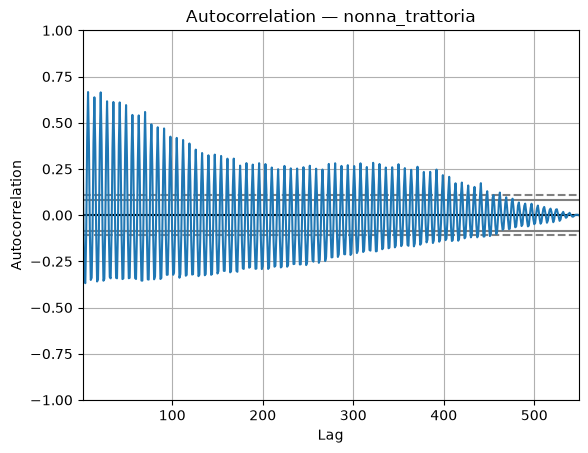

In [ ]:
from pandas.plotting import autocorrelation_plot

biz = "nonna_trattoria"
sub = df[df["business_id"] == biz].set_index("date")["revenue"]
sub = sub.reindex(full_range)  # fill missing dates 

autocorrelation_plot(sub.dropna())
plt.title(f"Autocorrelation — {biz}")
plt.show()

### marketing spend vs revenue


In [34]:
for biz in df["business_id"].unique():
    sub = df[df["business_id"] == biz]
    mkt = sub[sub["marketing_spend"] > 0]["revenue"].mean()
    no_mkt = sub[sub["marketing_spend"] == 0]["revenue"].mean()
    n = len(sub[sub["marketing_spend"] > 0])
    print(f"{biz}: spend_days={n}, lift={((mkt/no_mkt)-1)*100:.1f}%")

blue_bottle_cafe: spend_days=32, lift=29.0%
corner_bakery: spend_days=2, lift=6.1%
evergreen_boutique: spend_days=16, lift=-2.0%
iron_pulse_gym: spend_days=15, lift=13.3%
nonna_trattoria: spend_days=29, lift=55.8%
shear_genius_salon: spend_days=27, lift=13.6%
